# DDR Diabetic Retinopathy — Fast Full Colab Pipeline

Actual dataset structure:

```text
MyDrive/DDR dataset/
├── DR_grading/
│   └── *.jpg
└── DR_grading.csv
```

CSV columns: `id_code`, `diagnosis`.

The notebook selects up to 1,000 unique images per class, creates a stratified 70/15/15 split, copies only the selected images to Colab local storage, trains four transfer-learning models with mixed precision, and generates evaluation graphs/results.

For your data, classes with fewer than 1,000 images are kept in full; images are never duplicated.


In [1]:
# 1. INSTALL AND IMPORT

!pip -q install opencv-python-headless scikit-learn seaborn

import gc, time, copy, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    efficientnet_v2_s, EfficientNet_V2_S_Weights,
    resnet50, ResNet50_Weights,
    densenet121, DenseNet121_Weights
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, cohen_kappa_score, confusion_matrix,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cpu
Device: cpu


In [2]:
# 2. MOUNT DRIVE

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
# 3. PATHS

BASE_DIR = Path("/content/drive/MyDrive/DDR dataset/DR_grading")
IMAGE_DIR = BASE_DIR / "DR_grading"
CSV_PATH = BASE_DIR / "DR_grading.csv"

RESULTS_ROOT = BASE_DIR / "DDR_fast_results"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Image folder not found: {IMAGE_DIR}")

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

print("Image folder:", IMAGE_DIR)
print("CSV:", CSV_PATH)
print("Results:", RESULTS_ROOT)


Image folder: /content/drive/MyDrive/DDR dataset/DR_grading/DR_grading
CSV: /content/drive/MyDrive/DDR dataset/DR_grading/DR_grading.csv
Results: /content/drive/MyDrive/DDR dataset/DR_grading/DDR_fast_results


In [4]:
# 4. LOAD CSV AND MATCH DIRECT JPG FILES

df = pd.read_csv(CSV_PATH)

print("CSV shape:", df.shape)
print("Columns:", df.columns.tolist())

# Actual DDR columns
image_column = "id_code"
label_column = "diagnosis"

if image_column not in df.columns or label_column not in df.columns:
    raise ValueError(
        f"Expected columns 'id_code' and 'diagnosis'. Found: {df.columns.tolist()}"
    )

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_files = [
    f for f in IMAGE_DIR.iterdir()
    if f.is_file() and f.suffix.lower() in extensions
]

available = {f.name for f in image_files}

def find_image(x):
    x = str(x).strip()
    if x in available:
        return x
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
        if x + ext in available:
            return x + ext
    return None

data = df[[image_column, label_column]].copy()
data.columns = ["filename", "grade"]
data["grade"] = pd.to_numeric(data["grade"], errors="coerce")
data = data.dropna(subset=["grade"]).copy()
data["grade"] = data["grade"].astype(int)

tqdm.pandas()
data["filename"] = data["filename"].progress_apply(find_image)
data = data.dropna(subset=["filename"]).reset_index(drop=True)

print("Images found:", len(image_files))
print("Usable labelled images:", len(data))
print("\nClass distribution:")
print(data["grade"].value_counts().sort_index())


CSV shape: (12522, 2)
Columns: ['id_code', 'diagnosis']


  0%|          | 0/12522 [00:00<?, ?it/s]

Images found: 12524
Usable labelled images: 12522

Class distribution:
grade
0    6266
1     630
2    4477
3     236
4     913
Name: count, dtype: int64


In [5]:
# 5. SELECT UP TO 1,000 UNIQUE IMAGES PER CLASS

NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
SAMPLES_PER_CLASS = 1000

parts = []

for grade in range(NUM_CLASSES):
    class_df = data[data["grade"] == grade]
    n = min(SAMPLES_PER_CLASS, len(class_df))
    print(f"{grade} - {CLASS_NAMES[grade]}: {len(class_df)} available -> {n} selected")
    parts.append(class_df.sample(n=n, random_state=SEED))

sampled_data = (
    pd.concat(parts, ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("\nTotal selected:", len(sampled_data))
print(sampled_data["grade"].value_counts().sort_index())

sampled_data.to_csv(
    RESULTS_ROOT / "selected_ddr_dataset.csv",
    index=False
)


0 - No DR: 6266 available -> 1000 selected
1 - Mild: 630 available -> 630 selected
2 - Moderate: 4477 available -> 1000 selected
3 - Severe: 236 available -> 236 selected
4 - Proliferative DR: 913 available -> 913 selected

Total selected: 3779
grade
0    1000
1     630
2    1000
3     236
4     913
Name: count, dtype: int64


In [6]:
# 6. STRATIFIED 70/15/15 SPLIT

train_df, temp_df = train_test_split(
    sampled_data,
    test_size=0.30,
    stratify=sampled_data["grade"],
    random_state=SEED
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["grade"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(valid_df))
print("Test:", len(test_df))

train_df.to_csv(RESULTS_ROOT / "train.csv", index=False)
valid_df.to_csv(RESULTS_ROOT / "validation.csv", index=False)
test_df.to_csv(RESULTS_ROOT / "test.csv", index=False)


Train: 2645
Validation: 567
Test: 567


In [7]:
# 7. COPY ONLY SELECTED IMAGES TO LOCAL COLAB STORAGE
# This avoids slow repeated Google Drive image reads.

LOCAL_IMAGE_DIR = Path("/content/DDR_fast")
LOCAL_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

files_to_copy = sampled_data["filename"].unique()

print("Copying", len(files_to_copy), "selected images...")

for filename in tqdm(files_to_copy):
    src = IMAGE_DIR / filename
    dst = LOCAL_IMAGE_DIR / filename
    if not dst.exists():
        shutil.copy2(src, dst)

print("Local images:", LOCAL_IMAGE_DIR)


Copying 3779 selected images...


  0%|          | 0/3779 [00:00<?, ?it/s]

Local images: /content/DDR_fast


In [8]:
# 8. FAST PREPROCESSING AND TRANSFORMS

IMG_SIZE = 224

def preprocess_fundus(image):
    img = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 10

    if mask.sum() > 0:
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        img = img[y0:y1, x0:x1]

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

    return Image.fromarray(img)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


In [9]:
# 9. DATASET AND FAST DATALOADERS
# num_workers=0 fixes the Colab multiprocessing warning.

class DDRDataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(
            LOCAL_IMAGE_DIR / row["filename"]
        ).convert("RGB")
        image = preprocess_fundus(image)

        if self.transform:
            image = self.transform(image)

        return image, int(row["grade"])


train_dataset = DDRDataset(train_df, train_transform)
valid_dataset = DDRDataset(valid_df, eval_transform)
test_dataset = DDRDataset(test_df, eval_transform)

BATCH_SIZE = 32 if torch.cuda.is_available() else 8
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Batch size:", BATCH_SIZE)
print("Workers:", NUM_WORKERS)


Batch size: 8
Workers: 0


In [10]:
# 10. CLASS WEIGHTS

weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["grade"].values
)

class_weights = torch.tensor(
    weights_np,
    dtype=torch.float32,
    device=device
)

print(dict(zip(CLASS_NAMES, weights_np.round(3))))

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


{'No DR': np.float64(0.756), 'Mild': np.float64(1.2), 'Moderate': np.float64(0.756), 'Severe': np.float64(3.206), 'Proliferative DR': np.float64(0.828)}


In [11]:
# 11. MODEL FACTORY

ARCHITECTURES = [
    "EfficientNetB0",
    "EfficientNetV2-S",
    "ResNet50",
    "DenseNet121"
]

def build_model(name):

    if name == "EfficientNetB0":
        model = efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )
        head = "classifier"

    elif name == "EfficientNetV2-S":
        model = efficientnet_v2_s(
            weights=EfficientNet_V2_S_Weights.DEFAULT
        )
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )
        head = "classifier"

    elif name == "ResNet50":
        model = resnet50(
            weights=ResNet50_Weights.DEFAULT
        )
        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )
        head = "fc"

    elif name == "DenseNet121":
        model = densenet121(
            weights=DenseNet121_Weights.DEFAULT
        )
        model.classifier = nn.Linear(
            model.classifier.in_features,
            NUM_CLASSES
        )
        head = "classifier"

    else:
        raise ValueError(name)

    return model.to(device), head


def freeze_backbone(model, head):
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith(head)


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True


In [12]:
# 12. METRICS

def calculate_metrics(y_true, y_pred, y_prob):

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(y_true, y_pred)

    qwk = cohen_kappa_score(
        y_true,
        y_pred,
        weights="quadratic"
    )

    try:
        y_bin = label_binarize(
            y_true,
            classes=np.arange(NUM_CLASSES)
        )

        auc_score = roc_auc_score(
            y_bin,
            y_prob,
            average="weighted",
            multi_class="ovr"
        )

    except Exception:
        auc_score = np.nan

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "AUC": auc_score,
        "QWK": qwk
    }


In [13]:
# 13. FAST TRAIN / PREDICT FUNCTIONS

USE_AMP = torch.cuda.is_available()

def train_epoch(model, loader, optimizer, scaler):

    model.train()
    total_loss = 0.0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=USE_AMP
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict(model, loader):

    model.eval()

    y_true, y_pred, y_prob = [], [], []

    for images, labels in loader:

        images = images.to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=USE_AMP
        ):
            outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

    return (
        np.asarray(y_true),
        np.asarray(y_pred),
        np.asarray(y_prob)
    )

print("AMP enabled:", USE_AMP)


AMP enabled: False


In [14]:
# ============================================================
# 14. FAST TRAIN ALL FOUR MODELS
# ============================================================

HEAD_EPOCHS = 1
FINETUNE_EPOCHS = 2

HEAD_LR = 1e-3
FINETUNE_LR = 1e-4
WEIGHT_DECAY = 1e-4

all_results = []
all_histories = {}
all_predictions = {}
trained_models = {}


def run_model_fast(architecture):

    print("\n" + "=" * 55)
    print("TRAINING:", architecture)
    print("=" * 55)

    start = time.time()

    model, head = build_model(architecture)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_accuracy": [],
        "val_f1": [],
        "val_qwk": []
    }

    best_qwk = -np.inf
    best_state = None
    epoch_no = 0

    # Head training
    freeze_backbone(model, head)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=HEAD_LR,
        weight_decay=WEIGHT_DECAY
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

    for _ in range(HEAD_EPOCHS):

        epoch_no += 1

        loss = train_epoch(
            model,
            train_loader,
            optimizer,
            scaler
        )

        yv, pv, probv = predict(
            model,
            valid_loader
        )

        m = calculate_metrics(
            yv,
            pv,
            probv
        )

        history["epoch"].append(epoch_no)
        history["train_loss"].append(loss)
        history["val_accuracy"].append(m["Accuracy"])
        history["val_f1"].append(m["F1-score"])
        history["val_qwk"].append(m["QWK"])

        print(
            f"Epoch {epoch_no} | "
            f"Loss={loss:.4f} | "
            f"F1={m['F1-score']:.4f} | "
            f"QWK={m['QWK']:.4f}"
        )

        if m["QWK"] > best_qwk:
            best_qwk = m["QWK"]
            best_state = copy.deepcopy(model.state_dict())

    # Fine-tuning
    unfreeze_all(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=FINETUNE_LR,
        weight_decay=WEIGHT_DECAY
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

    for _ in range(FINETUNE_EPOCHS):

        epoch_no += 1

        loss = train_epoch(
            model,
            train_loader,
            optimizer,
            scaler
        )

        yv, pv, probv = predict(
            model,
            valid_loader
        )

        m = calculate_metrics(
            yv,
            pv,
            probv
        )

        history["epoch"].append(epoch_no)
        history["train_loss"].append(loss)
        history["val_accuracy"].append(m["Accuracy"])
        history["val_f1"].append(m["F1-score"])
        history["val_qwk"].append(m["QWK"])

        print(
            f"Epoch {epoch_no} | "
            f"Loss={loss:.4f} | "
            f"F1={m['F1-score']:.4f} | "
            f"QWK={m['QWK']:.4f}"
        )

        if m["QWK"] > best_qwk:
            best_qwk = m["QWK"]
            best_state = copy.deepcopy(model.state_dict())

    # Best validation model
    model.load_state_dict(best_state)

    # Test
    yt, pt, probt = predict(
        model,
        test_loader
    )

    metrics = calculate_metrics(
        yt,
        pt,
        probt
    )

    elapsed = time.time() - start

    metrics["Model"] = architecture
    metrics["Training_time_sec"] = elapsed

    filename = (
        architecture.lower()
        .replace("-", "_")
        .replace(" ", "_")
        + "_best.pth"
    )

    torch.save(
        model.state_dict(),
        RESULTS_ROOT / filename
    )

    return (
        model,
        metrics,
        history,
        yt,
        pt,
        probt
    )


for architecture in ARCHITECTURES:

    try:

        (
            model,
            metrics,
            history,
            yt,
            pt,
            probt
        ) = run_model_fast(
            architecture
        )

        all_results.append(metrics)

        all_histories[architecture] = history

        all_predictions[architecture] = {
            "y_true": yt,
            "y_pred": pt,
            "y_prob": probt
        }

        trained_models[architecture] = model

        print(
            f"Completed: {architecture}"
        )

    except RuntimeError as e:

        if "out of memory" in str(e).lower():

            print(
                f"GPU memory error: {architecture}. "
                "Try BATCH_SIZE = 16."
            )

            torch.cuda.empty_cache()

        else:
            raise

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


results_df = pd.DataFrame(all_results)

if len(results_df):

    results_df = results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "AUC",
            "QWK",
            "Training_time_sec"
        ]
    ].sort_values(
        "F1-score",
        ascending=False
    ).reset_index(drop=True)

    display(results_df.round(4))

    results_df.to_csv(
        RESULTS_ROOT /
        "model_comparison_results.csv",
        index=False
    )



TRAINING: EfficientNetB0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s] 


Epoch 1 | Loss=1.3133 | F1=0.5170 | QWK=0.7478
Epoch 2 | Loss=1.0958 | F1=0.5947 | QWK=0.8165
Epoch 3 | Loss=0.9144 | F1=0.6490 | QWK=0.8323
Completed: EfficientNetB0

TRAINING: EfficientNetV2-S
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 234MB/s]


Epoch 1 | Loss=1.3554 | F1=0.5154 | QWK=0.7026
Epoch 2 | Loss=1.1300 | F1=0.6018 | QWK=0.7978
Epoch 3 | Loss=0.9423 | F1=0.6660 | QWK=0.8481
Completed: EfficientNetV2-S

TRAINING: ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


Epoch 1 | Loss=1.3710 | F1=0.5713 | QWK=0.7521
Epoch 2 | Loss=1.0645 | F1=0.6170 | QWK=0.8482
Epoch 3 | Loss=0.8616 | F1=0.6523 | QWK=0.8543
Completed: ResNet50

TRAINING: DenseNet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 154MB/s]


Epoch 1 | Loss=1.3661 | F1=0.4454 | QWK=0.7208
Epoch 2 | Loss=1.0912 | F1=0.5554 | QWK=0.7531
Epoch 3 | Loss=0.9186 | F1=0.6320 | QWK=0.8483
Completed: DenseNet121


,Model,Accuracy,Precision,Recall,F1-score,AUC,QWK,Training_time_sec
0,ResNet50,0.6843,0.7002,0.6843,0.6793,0.9036,0.8614,3775.4799
1,EfficientNetV2-S,0.6367,0.6709,0.6367,0.6467,0.8893,0.8411,3333.2139
2,EfficientNetB0,0.6208,0.6528,0.6208,0.6248,0.8832,0.8150,1655.3542
3,DenseNet121,0.6190,0.6775,0.6190,0.6211,0.8922,0.8292,3105.8821


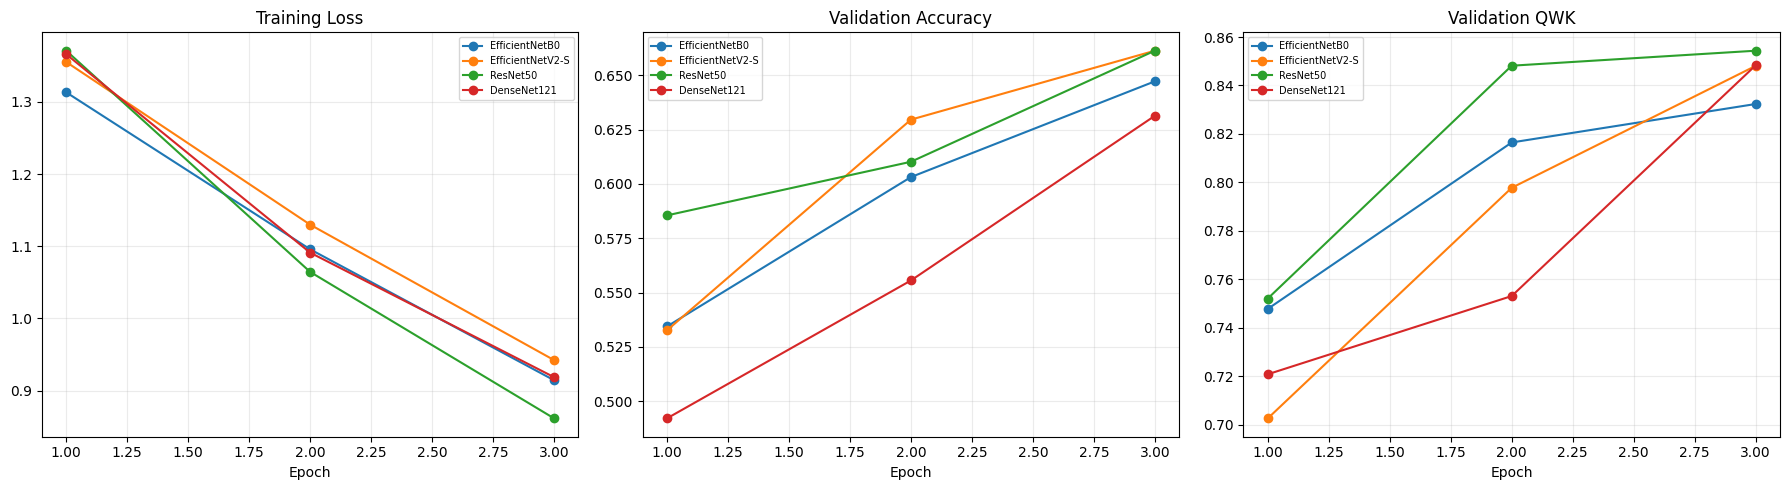

In [15]:
# 15. TRAINING CURVES

if all_histories:

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 5)
    )

    for name, h in all_histories.items():

        axes[0].plot(
            h["epoch"],
            h["train_loss"],
            marker="o",
            label=name
        )

        axes[1].plot(
            h["epoch"],
            h["val_accuracy"],
            marker="o",
            label=name
        )

        axes[2].plot(
            h["epoch"],
            h["val_qwk"],
            marker="o",
            label=name
        )

    axes[0].set_title("Training Loss")
    axes[1].set_title("Validation Accuracy")
    axes[2].set_title("Validation QWK")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=7)

    plt.tight_layout()

    plt.savefig(
        RESULTS_ROOT / "04_training_curves.png",
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()


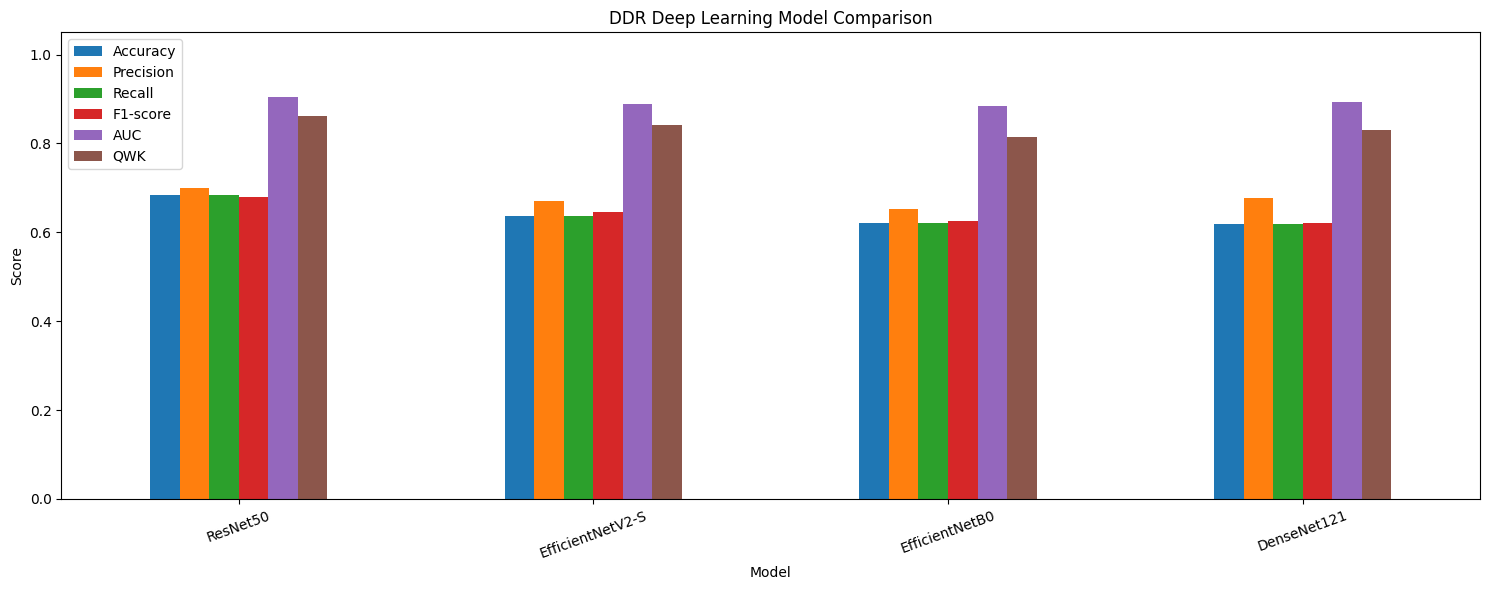

In [16]:
# 16. MODEL COMPARISON GRAPH

if len(results_df):

    metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC",
        "QWK"
    ]

    ax = (
        results_df
        .set_index("Model")[metrics]
        .plot(
            kind="bar",
            figsize=(15, 6)
        )
    )

    ax.set_title(
        "DDR Deep Learning Model Comparison"
    )

    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)

    plt.xticks(rotation=20)
    plt.tight_layout()

    plt.savefig(
        RESULTS_ROOT / "05_model_comparison.png",
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()


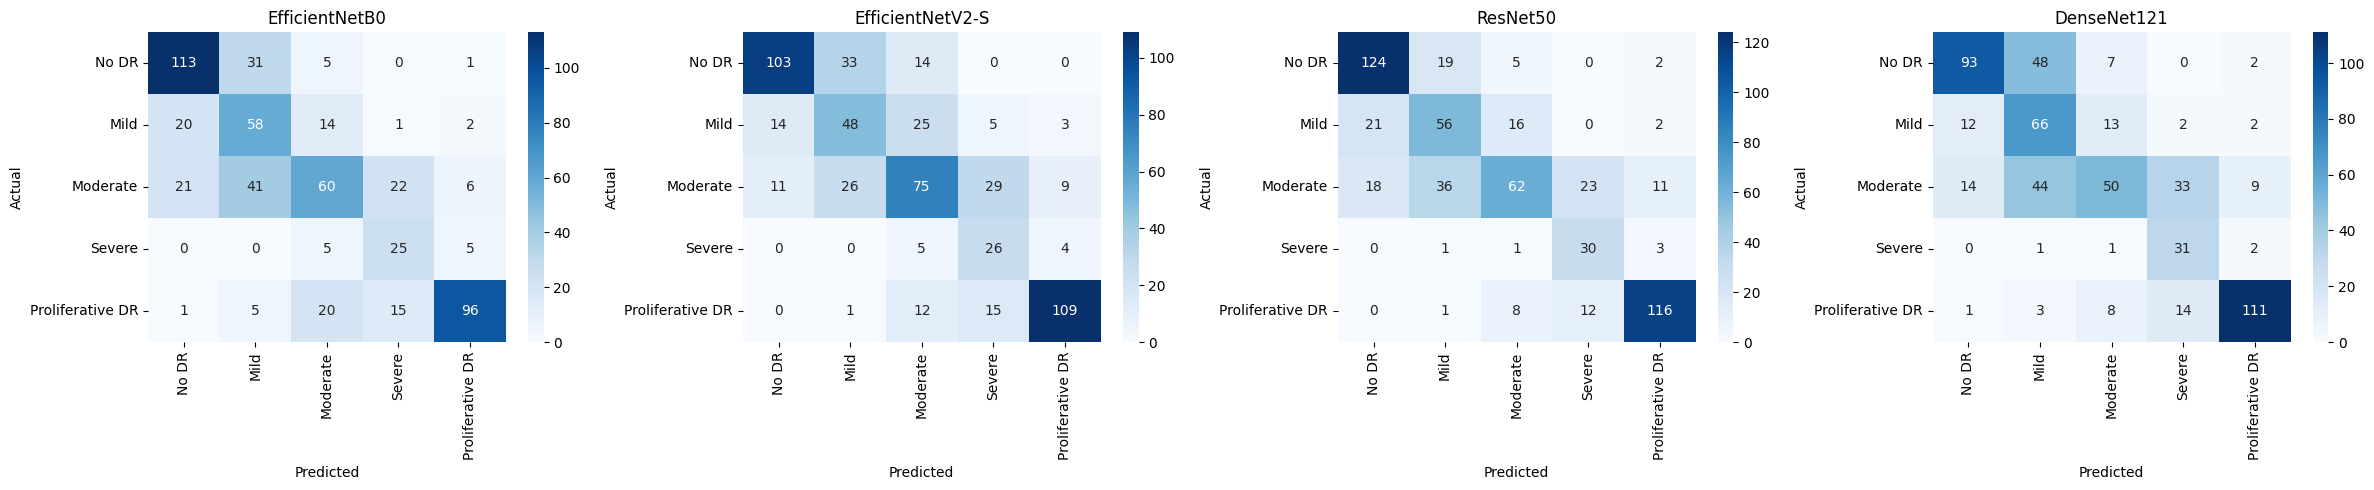

In [17]:
# 17. CONFUSION MATRICES

n_models = len(all_predictions)

if n_models:

    fig, axes = plt.subplots(
        1,
        n_models,
        figsize=(6 * n_models, 5)
    )

    if n_models == 1:
        axes = [axes]

    for ax, (name, pred) in zip(
        axes,
        all_predictions.items()
    ):

        cm = confusion_matrix(
            pred["y_true"],
            pred["y_pred"],
            labels=range(NUM_CLASSES)
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=ax
        )

        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()

    plt.savefig(
        RESULTS_ROOT / "06_confusion_matrices.png",
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()


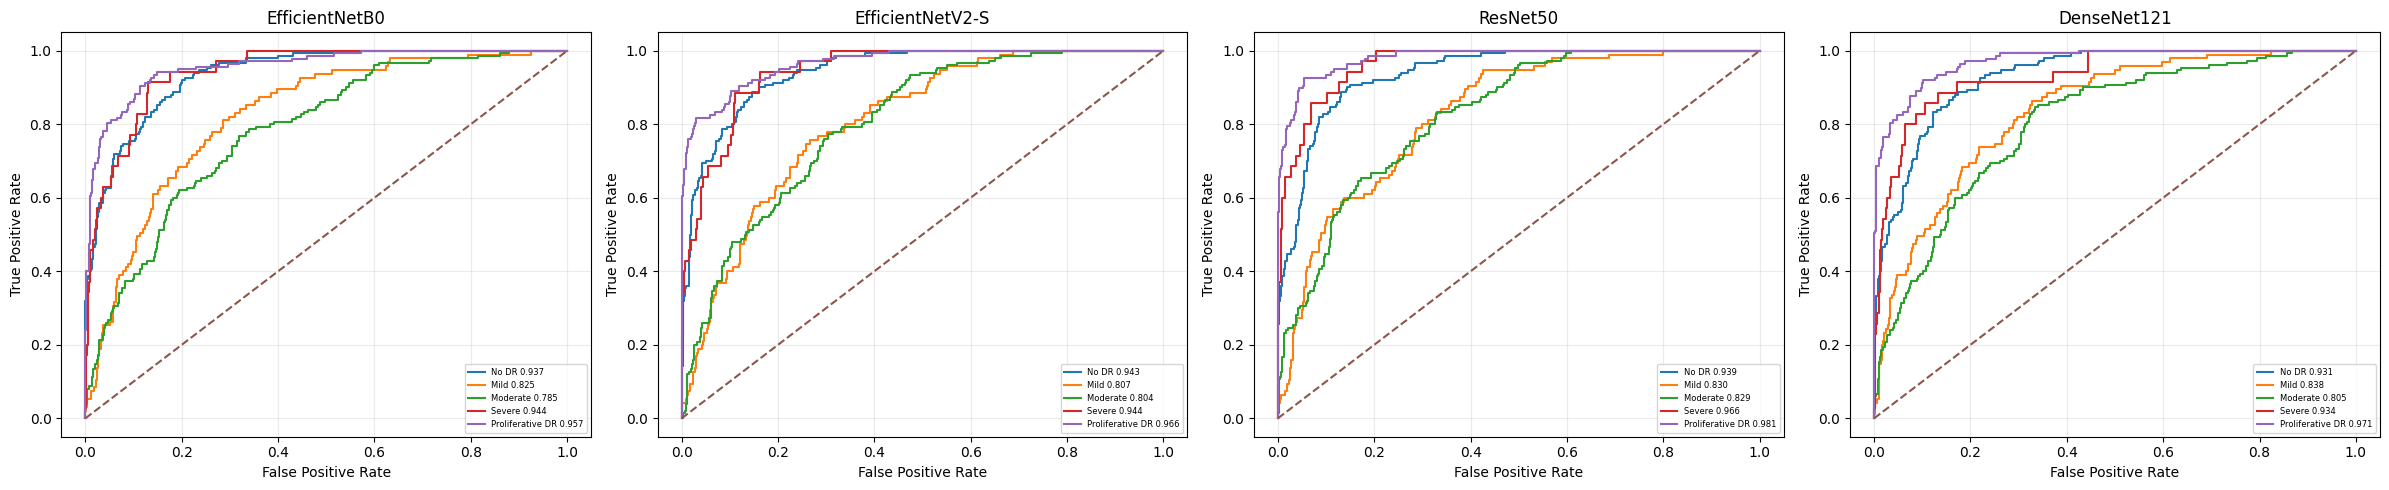

In [18]:
# 18. ROC CURVES

if n_models:

    fig, axes = plt.subplots(
        1,
        n_models,
        figsize=(6 * n_models, 5)
    )

    if n_models == 1:
        axes = [axes]

    for ax, (name, pred) in zip(
        axes,
        all_predictions.items()
    ):

        ybin = label_binarize(
            pred["y_true"],
            classes=range(NUM_CLASSES)
        )

        for i in range(NUM_CLASSES):

            fpr, tpr, _ = roc_curve(
                ybin[:, i],
                pred["y_prob"][:, i]
            )

            class_auc = auc(fpr, tpr)

            ax.plot(
                fpr,
                tpr,
                label=f"{CLASS_NAMES[i]} {class_auc:.3f}"
            )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--"
        )

        ax.set_title(name)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(fontsize=6)
        ax.grid(alpha=0.25)

    plt.tight_layout()

    plt.savefig(
        RESULTS_ROOT / "07_roc_curves.png",
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()


In [19]:
# 19. PER-CLASS METRICS

rows = []

for name, pred in all_predictions.items():

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            pred["y_true"],
            pred["y_pred"],
            labels=range(NUM_CLASSES),
            zero_division=0
        )
    )

    for i in range(NUM_CLASSES):

        rows.append({
            "Model": name,
            "Grade": i,
            "Class": CLASS_NAMES[i],
            "Precision": precision[i],
            "Recall": recall[i],
            "F1-score": f1[i],
            "Support": support[i]
        })

per_class_df = pd.DataFrame(rows)

display(
    per_class_df.round(4)
)

per_class_df.to_csv(
    RESULTS_ROOT /
    "per_class_metrics.csv",
    index=False
)


,Model,Grade,Class,Precision,Recall,F1-score,Support
0,EfficientNetB0,0,No DR,0.7290,0.7533,0.7410,150
1,EfficientNetB0,1,Mild,0.4296,0.6105,0.5043,95
2,EfficientNetB0,2,Moderate,0.5769,0.4000,0.4724,150
3,EfficientNetB0,3,Severe,0.3968,0.7143,0.5102,35
4,EfficientNetB0,4,Proliferative DR,0.8727,0.7007,0.7773,137
5,EfficientNetV2-S,0,No DR,0.8047,0.6867,0.7410,150
6,EfficientNetV2-S,1,Mild,0.4444,0.5053,0.4729,95
7,EfficientNetV2-S,2,Moderate,0.5725,0.5000,0.5338,150
8,EfficientNetV2-S,3,Severe,0.3467,0.7429,0.4727,35
9,EfficientNetV2-S,4,Proliferative DR,0.8720,0.7956,0.8321,137


In [20]:
# 20. BEST MODEL REPORT

if len(results_df):

    best_model = results_df.iloc[0]["Model"]

    pred = all_predictions[best_model]

    print("Best model:", best_model)

    report = classification_report(
        pred["y_true"],
        pred["y_pred"],
        labels=range(NUM_CLASSES),
        target_names=CLASS_NAMES,
        zero_division=0
    )

    print(report)

    with open(
        RESULTS_ROOT /
        "best_model_classification_report.txt",
        "w",
        encoding="utf-8"
    ) as f:
        f.write(report)


Best model: ResNet50
                  precision    recall  f1-score   support

           No DR       0.76      0.83      0.79       150
            Mild       0.50      0.59      0.54        95
        Moderate       0.67      0.41      0.51       150
          Severe       0.46      0.86      0.60        35
Proliferative DR       0.87      0.85      0.86       137

        accuracy                           0.68       567
       macro avg       0.65      0.71      0.66       567
    weighted avg       0.70      0.68      0.68       567



In [21]:
# 21. FINAL SUMMARY + ZIP

summary = pd.DataFrame([{
    "Original_usable_images": len(data),
    "Selected_images": len(sampled_data),
    "Train_images": len(train_df),
    "Validation_images": len(valid_df),
    "Test_images": len(test_df),
    "Classes": NUM_CLASSES,
    "Image_size": IMG_SIZE,
    "Batch_size": BATCH_SIZE,
    "Models_completed": len(results_df),
    "Best_model": (
        results_df.iloc[0]["Model"]
        if len(results_df)
        else "None"
    ),
    "Device": str(device)
}])

display(summary)

summary.to_csv(
    RESULTS_ROOT /
    "experiment_summary.csv",
    index=False
)

zip_path = shutil.make_archive(
    str(BASE_DIR / "DDR_fast_results"),
    "zip",
    root_dir=RESULTS_ROOT
)

print("Results:", RESULTS_ROOT)
print("ZIP:", zip_path)


,Original_usable_images,Selected_images,Train_images,Validation_images,Test_images,Classes,Image_size,Batch_size,Models_completed,Best_model,Device
0,12522,3779,2645,567,567,5,224,8,4,ResNet50,cpu


Results: /content/drive/MyDrive/DDR dataset/DR_grading/DDR_fast_results
ZIP: /content/drive/MyDrive/DDR dataset/DR_grading/DDR_fast_results.zip
